# US MASS SHOOTINGS

DataSet Link: https://www.kaggle.com/datasets/zusmani/us-mass-shootings-last-50-years

### INTRODUCTION
In recent years, communities across the United States have been deeply shaken by a troubling rise in mass shootings. These events not only leave scars on the affected areas but also ignite urgent conversations about crucial issues like gun control, mental health support, and public safety measures. Mass shootings, characterized by the deliberate targeting of multiple individuals in public places, have sadly become all too familiar throughout the nation. They strike at the heart of society, impacting places like schools, workplaces, entertainment venues, and even places of worship. 
These tragic events not only claim lives but also leave enduring scars on communities, families, and individuals. Each incident represents more than just a statistic; it represents shattered dreams, lost opportunities, and irreplaceable loved ones. The aftermath of a mass shooting extends far beyond the immediate physical harm, encompassing emotional trauma, psychological distress, and long-term societal repercussions. As we embark on this study, we recognize the importance of not only understanding the factors contributing to these tragedies but also advocating for meaningful change to prevent future occurrences. By confronting the stark realities of mass shootings, we hope to contribute to a collective effort aimed at fostering safer, more resilient communities for all. In this exploration, we aim to shed light on the harsh reality of mass shootings in the US, uncovering their frequency, root causes, and profound effects on communities.

Over the past five decades, the United States has experienced a total of 398 mass shootings, spanning from 1966 to 2017. These devastating events have resulted in the loss of 1,996 lives and left 2,488 individuals injured. Among these incidents, the most recent and severe occurred on October 2, 2017, claiming the lives of 58 individuals and leaving 515 wounded. Notably, the number of injuries sustained in this single attack surpasses the combined total of injuries from all mass shootings that occurred in 2015 and 2016. On average, there have been approximately 7 mass shootings annually over the past 50 years, resulting in an average of 39 fatalities and 48 injuries per year.

Dataset Characteristics:

Geography: United States of America
Time Period: 1966-2017
Unit of Analysis: Mass Shooting Attacks
Dataset Content: Detailed information on 398 mass shootings in the United States, documenting 1,996 fatalities and 2,488 injuries.

Through data analysis and critical examination, we seek to shed light on this pressing issue and explore avenues for prevention and intervention to ensure the safety and well-being of all citizens.

### Motivation
Understanding the prevalence and patterns of mass shootings in the United States is not just a matter of statistical analysis; it is a critical examination of a pressing societal issue that affects communities nationwide. By delving into the data surrounding these tragic events, we aim to shed light on the underlying factors contributing to mass shootings and their devastating impact on individuals, families, and society as a whole. This research is motivated by a fundamental concern for public safety and the well-being of all citizens. By uncovering insights into the frequency, causes, and consequences of mass shootings, we hope to inform evidence-based policy decisions aimed at reducing the incidence of these violent incidents and ultimately creating safer environments for everyone. In a world where the threat of mass violence looms large, understanding the nuances of this issue is not just academic curiosity; it is a vital step towards fostering a safer and more resilient society for generations to come.

### Contribution
Our approach to analyzing mass shootings in the United States offers several novel contributions to the existing literature. Firstly, we employ advanced data visualization techniques to unravel complex patterns and trends within the dataset, providing a comprehensive understanding of the spatial and temporal dynamics of mass shootings. Unlike previous studies that primarily focus on aggregate statistics, our analysis delves deeper into the underlying factors driving these incidents, including socio-economic disparities, access to firearms, and mental health issues. Additionally, we adopt a multidisciplinary perspective, drawing insights from fields such as criminology, sociology, and public health to offer a holistic understanding of the phenomenon. By integrating qualitative and quantitative methods, we aim to uncover nuanced insights that have eluded previous analyses, thereby shedding new light on this pressing societal issue. Ultimately, our research not only contributes to the academic discourse on mass shootings but also informs evidence-based policy interventions aimed at preventing future tragedies.

### Data Description

Incident Area - (location of the incident),  
Open/Close Location- (indoor or outdoor setting),  
Target (potential victims or affected group),  
Cause (motivation or reason behind the incident, such as terrorism, hate crime, or random act),  
Policeman Killed (number of on-duty officers fatally injured),  
Age (age of the perpetrator),  
Employed (yes/no employment status),  
Employed at (name of the employer/company where the perpetrator works)

### Required packages and Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from geopy.geocoders import Nominatim
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display
import folium
from folium.plugins import HeatMap

%matplotlib inline
path = "https://raw.githubusercontent.com/chetan-957/DV-final-project/main/Mass%20Shootings%20Dataset%20Ver%205.csv"
df = pd.read_csv(path, encoding='latin1')
df.head(5) #prints 1st 5 rows in the Data Set

ModuleNotFoundError: No module named 'numpy'

In [2]:
df.columns # prints all the colomn names from the Data Set

Index(['S#', 'Title', 'Location', 'Date', 'Incident Area',
       'Open/Close Location', 'Target', 'Cause', 'Summary', 'Fatalities',
       'Injured', 'Total victims', 'Policeman Killed', 'Age',
       'Employeed (Y/N)', 'Employed at', 'Mental Health Issues', 'Race',
       'Gender', 'Latitude', 'Longitude'],
      dtype='object')

In [3]:
df.shape #shows the No.of rows and colomns present in the Data Set

(323, 21)

In [4]:
df.isnull().sum()

S#                        0
Title                     0
Location                 45
Date                      0
Incident Area            62
Open/Close Location      28
Target                    5
Cause                    77
Summary                   0
Fatalities                0
Injured                   0
Total victims             0
Policeman Killed          6
Age                     144
Employeed (Y/N)         256
Employed at             282
Mental Health Issues      0
Race                      2
Gender                    0
Latitude                 20
Longitude                20
dtype: int64

In [5]:
df.duplicated().sum().sum()

0

In [6]:
df.info() # to provides a concise summary of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 323 entries, 0 to 322
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   S#                    323 non-null    int64  
 1   Title                 323 non-null    object 
 2   Location              278 non-null    object 
 3   Date                  323 non-null    object 
 4   Incident Area         261 non-null    object 
 5   Open/Close Location   295 non-null    object 
 6   Target                318 non-null    object 
 7   Cause                 246 non-null    object 
 8   Summary               323 non-null    object 
 9   Fatalities            323 non-null    int64  
 10  Injured               323 non-null    int64  
 11  Total victims         323 non-null    int64  
 12  Policeman Killed      317 non-null    float64
 13  Age                   179 non-null    object 
 14  Employeed (Y/N)       67 non-null     float64
 15  Employed at           4

In [7]:
Null_Percent = round(df.isnull().sum()*100/df.isnull().sum().sum(),2)
Null_Percent.sort_values(ascending=False)
#This code calculates the percentage of missing values (null values) in each column of the DataFrame `df` and sorts them in descending order based on the percentage of missing values. The result is stored in the variable `Null_Percent`.

Employed at             29.78
Employeed (Y/N)         27.03
Age                     15.21
Cause                    8.13
Incident Area            6.55
Location                 4.75
Open/Close Location      2.96
Longitude                2.11
Latitude                 2.11
Policeman Killed         0.63
Target                   0.53
Race                     0.21
Gender                   0.00
Mental Health Issues     0.00
S#                       0.00
Total victims            0.00
Title                    0.00
Fatalities               0.00
Summary                  0.00
Date                     0.00
Injured                  0.00
dtype: float64

In [8]:
df.describe().T # This shows the statistical summary for the DataFrame df

,count,mean,std,min,25%,50%,75%,max
S#,323.0,162.000000,93.386294,1.000000,81.500000,162.000000,242.500000,323.000000
Fatalities,323.0,4.436533,5.783208,0.000000,1.000000,3.000000,5.500000,59.000000
Injured,323.0,6.176471,29.889182,0.000000,1.000000,3.000000,5.000000,527.000000
Total victims,323.0,10.263158,33.662309,3.000000,4.000000,5.000000,9.000000,585.000000
Policeman Killed,317.0,0.129338,0.610294,0.000000,0.000000,0.000000,0.000000,5.000000
Employeed (Y/N),67.0,0.626866,0.487288,0.000000,0.000000,1.000000,1.000000,1.000000
Latitude,303.0,37.225076,5.536365,21.325512,33.571459,36.443290,41.483844,60.790539
Longitude,303.0,-94.429539,16.513296,-161.792752,-110.205485,-88.122998,-81.703237,-69.707823


### Data Cleaning

In [9]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)
#Shows the missing values of each colomn in the data frame

Missing Values:
 S#                        0
Title                     0
Location                 45
Date                      0
Incident Area            62
Open/Close Location      28
Target                    5
Cause                    77
Summary                   0
Fatalities                0
Injured                   0
Total victims             0
Policeman Killed          6
Age                     144
Employeed (Y/N)         256
Employed at             282
Mental Health Issues      0
Race                      2
Gender                    0
Latitude                 20
Longitude                20
dtype: int64


In [10]:
numeric_columns = df.select_dtypes(include=['number'])
numeric_columns.fillna(numeric_columns.mean(), inplace=True)
df.update(numeric_columns)

In [11]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 S#                        0
Title                     0
Location                 45
Date                      0
Incident Area            62
Open/Close Location      28
Target                    5
Cause                    77
Summary                   0
Fatalities                0
Injured                   0
Total victims             0
Policeman Killed          0
Age                     144
Employeed (Y/N)           0
Employed at             282
Mental Health Issues      0
Race                      2
Gender                    0
Latitude                  0
Longitude                 0
dtype: int64


In [12]:
for column in df.select_dtypes(include=['object']):
    df[column].fillna(df[column].mode()[0], inplace=True)


C:\Users\cheta\AppData\Local\Temp\ipykernel_136724\1405795755.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)


In [13]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 S#                      0
Title                   0
Location                0
Date                    0
Incident Area           0
Open/Close Location     0
Target                  0
Cause                   0
Summary                 0
Fatalities              0
Injured                 0
Total victims           0
Policeman Killed        0
Age                     0
Employeed (Y/N)         0
Employed at             0
Mental Health Issues    0
Race                    0
Gender                  0
Latitude                0
Longitude               0
dtype: int64


null values are cleared and we dont have any missing values

### Splitting Data
for Date and Location

In [14]:
# Split the 'Date' column into 'Month', 'Day', and 'Year'
df[['Month', 'Day', 'Year']] = df['Date'].str.split('/', expand=True)

# Split the 'Location' column into 'City' and 'State'
df[['City', 'State']] = df['Location'].str.split(',', n=1, expand=True)

# Display the first two rows of the DataFrame
df.head(5)



,S#,Title,Location,Date,Incident Area,Open/Close Location,Target,Cause,Summary,Fatalities,...,Mental Health Issues,Race,Gender,Latitude,Longitude,Month,Day,Year,City,State
0,1,Texas church mass shooting,"Sutherland Springs, TX",11/5/2017,Church,Close,random,unknown,"Devin Patrick Kelley, 26, an ex-air force offi...",26,...,No,White,M,37.225076,-94.429539,11,5,2017,Sutherland Springs,TX
1,2,Walmart shooting in suburban Denver,"Thornton, CO",11/1/2017,Wal-Mart,Open,random,unknown,"Scott Allen Ostrem, 47, walked into a Walmart ...",3,...,No,White,M,37.225076,-94.429539,11,1,2017,Thornton,CO
2,3,Edgewood businees park shooting,"Edgewood, MD",10/18/2017,Remodeling Store,Close,coworkers,unknown,"Radee Labeeb Prince, 37, fatally shot three pe...",3,...,No,Black,M,37.225076,-94.429539,10,18,2017,Edgewood,MD
3,4,Las Vegas Strip mass shooting,"Las Vegas, NV",10/1/2017,Las Vegas Strip Concert outside Mandala Bay,Open,random,unknown,"Stephen Craig Paddock, opened fire from the 32...",59,...,Unclear,White,M,36.181271,-115.134132,10,1,2017,Las Vegas,NV
4,5,San Francisco UPS shooting,"San Francisco, CA",6/14/2017,UPS facility,Close,coworkers,psycho,"Jimmy Lam, 38, fatally shot three coworkers an...",3,...,Yes,Asian,M,37.225076,-94.429539,6,14,2017,San Francisco,CA


In [15]:
df = df.replace({'State':{'LA' : "California", 'WA' : "Washington", "TX" : "Texas",
                         "PA":"Pennsylvania", "NV":"Nevada","MD":"Maryland", "CA":"California",
                         "CO": "Colorado" }})

df["State"].unique()


array([' TX', ' CO', ' MD', ' NV', ' CA', ' PA', ' Florida', ' Ohio',
       ' California', ' WA', ' LA', ' Texas', ' Missouri', ' Washington',
       ' Virginia', ' North Carolina', ' Tennessee', ' Texas ',
       ' Kentucky', ' Alabama', ' Pennsylvania', ' Kansas',
       ' Massachusetts', '  Virginia', ' Arizona', ' Michigan',
       ' Mississippi', ' Nebraska', ' Colorado', ' Minnesota', ' Georgia',
       ' Maine', ' Oregon', ' South Dakota', ' New York', ' Louisiana',
       ' Illinois', ' South Carolina', ' Wisconsin', ' Montana',
       ' New Jersey', ' Indiana', ' Oklahoma', ' New Mexico', ' Idaho',
       ' Souderton, Lansdale, Harleysville, Pennsylvania',
       ' West Virginia', ' Nevada', None, ' Albuquerque, New Mexico',
       ' Connecticut', ' Arkansas', ' Utah', ' Lancaster, Pennsylvania',
       ' Vermont', ' San Diego, California', ' Hawaii', ' Alaska',
       ' Wyoming', ' Iowa'], dtype=object)

In [16]:
df.groupby('State')[['Total victims', 'Injured', 'Fatalities']].sum().sort_values(['Total victims'], ascending=False).head(15).style.background_gradient(cmap='Greens')
#"Top States by Total Victims, Injured, Fatalities"

,Total victims,Injured,Fatalities
State,,,
NV,585,527,59
California,347,188,171
Washington,305,179,139
Texas,255,149,113
Florida,252,138,119
Colorado,148,109,43
New York,92,53,42
Georgia,81,47,40
Illinois,75,45,36


This provides a summary of the top states with the highest total number of victims in mass shooting incidents. It includes information about the total number of victims, the number of injured individuals, and the number of fatalities for each state. The states are ranked based on the total number of victims, with the highest-ranking states listed first. 

In [17]:
df.groupby('Year')[['Total victims', 'Injured', 'Fatalities']].sum().sort_values(['Total victims'], ascending=False).head(15).style.background_gradient(cmap='Blues')
#"Top Years with Highest Total Victims in Mass Shootings".

,Total victims,Injured,Fatalities
Year,,,
2017,670,558,113
2016,455,277,193
2015,395,200,226
2012,204,111,99
2007,123,61,65
2009,115,49,69
2014,112,76,45
2013,101,32,76
1999,97,56,45



This presents a table showing the top years with the highest total number of victims in mass shootings. Each row represents a year, and the columns display aggregated statistics including the total number of victims, injured individuals, and fatalities. The table is sorted in descending order based on the total number of victims. 

### BoxPlot

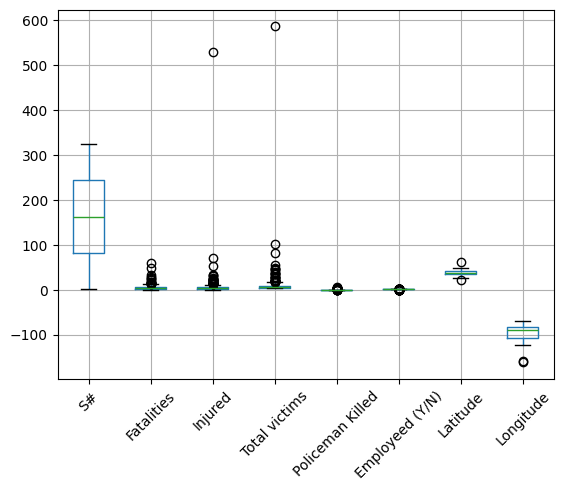

In [18]:
df.boxplot()
plt.xticks(rotation=45)
plt.show()

This box plot gives us a picture of how the data is spread out and whether there are any unusual values, called outliers, in different parts of the dataset. By looking at the box plot, we can see at a glance how the values are distributed and if there are any extreme points that might affect our analysis. This visualization helps us get a sense of the overall pattern and variability in the data, making it easier to understand the important statistical characteristics of our dataset.

### DateTime

In [19]:
df['Date'] = pd.to_datetime(df['Date'])  # Convert 'Date' column to datetime format
df['Year'] = df['Date'].dt.year  # Extracting the year from 'Date'

For easy Analysis and better visualization we can use "datetime" and get better insights

### PLOTS

#### A. The No. of Shootings by Year

C:\Users\cheta\AppData\Local\Temp\ipykernel_136724\3155524226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=df, palette='Reds')


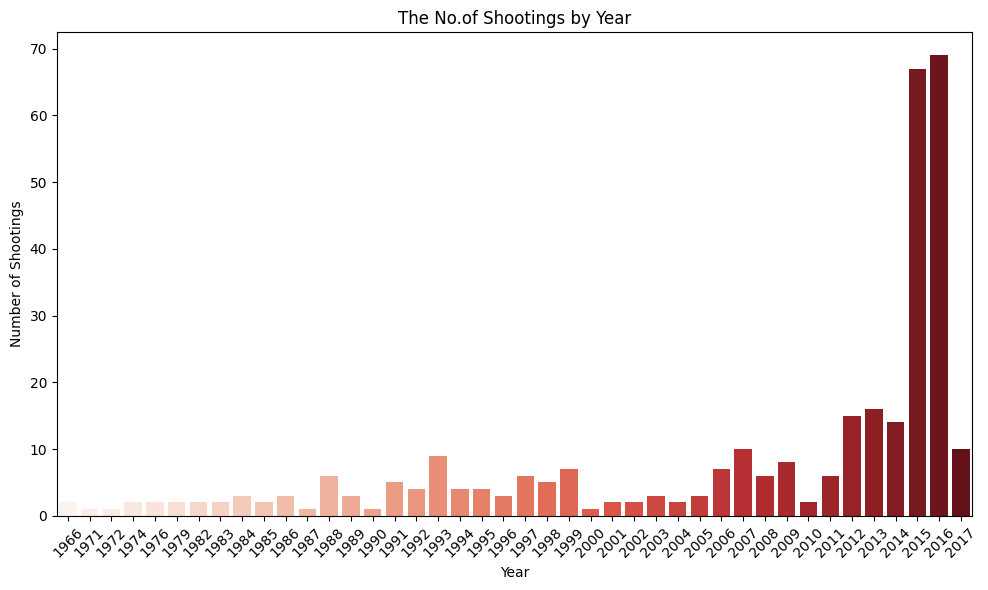

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Year', data=df, palette='Reds')
plt.title('The No.of Shootings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Shootings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Each bar represents a year, and its height indicates the frequency or count of shootings in that particular year. The x-axis shows the years from which the data is collected, and the y-axis represents the number of shootings.
By examining this plot, we can observe the distribution of shootings across different years and identify any trends or anomalies. In this specific dataset, 2016 stands out as having the highest number of shootings, followed by 2015 as the second highest.

#### B. Top10 states with most shootings

C:\Users\cheta\AppData\Local\Temp\ipykernel_136724\2253000167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Location', data=df, order=df['Location'].value_counts().iloc[:10].index, palette='Greens')


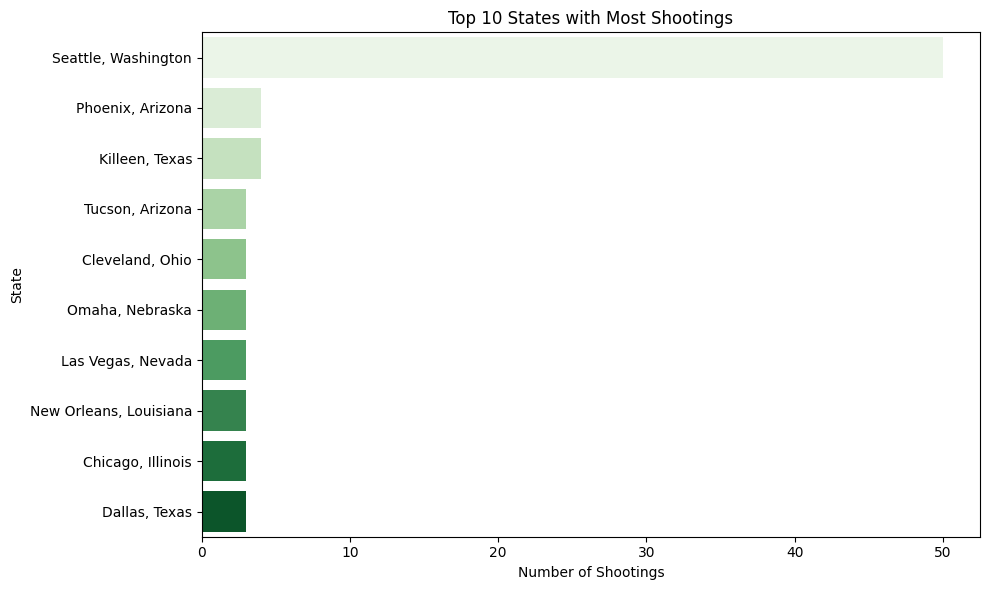

In [21]:
# Visualization: Geospatial analysis - Mapping incidents by location (states)
plt.figure(figsize=(10, 6))
sns.countplot(y='Location', data=df, order=df['Location'].value_counts().iloc[:10].index, palette='Greens')
plt.title('Top 10 States with Most Shootings')
plt.xlabel('Number of Shootings')
plt.ylabel('State')
plt.tight_layout()
plt.show()

Each bar represents a state, and its length corresponds to the count of shootings that occurred in that particular state. The y-axis displays the states, while the x-axis represents the number of shootings.
By analyzing this plot, we can identify the states where shootings are most prevalent. In this dataset, Seattle, Washington, stands out as the state with the highest number of shootings among the top 10 states.

In [22]:
# Filtered out rows where both Fatalities and Injuries are available
filtered_data = df.dropna(subset=['Fatalities', 'Injured'])

# Calculated the total Fatalities and Injuries for each of the incident
filtered_data['Total_Casualties'] = filtered_data['Fatalities'] + filtered_data['Injured']

# Sorted the incidents by total no.of casualties in descending order
filtered_data = filtered_data.sort_values(by='Total_Casualties', ascending=False)

# Selected top 10 incidents by total casualties for better and clean visualization
top_incidents = filtered_data.head(10)

Filtered the Data for further analysis

#### C. incidents per month

C:\Users\cheta\AppData\Local\Temp\ipykernel_136724\647965605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=filtered_data, palette='Paired')


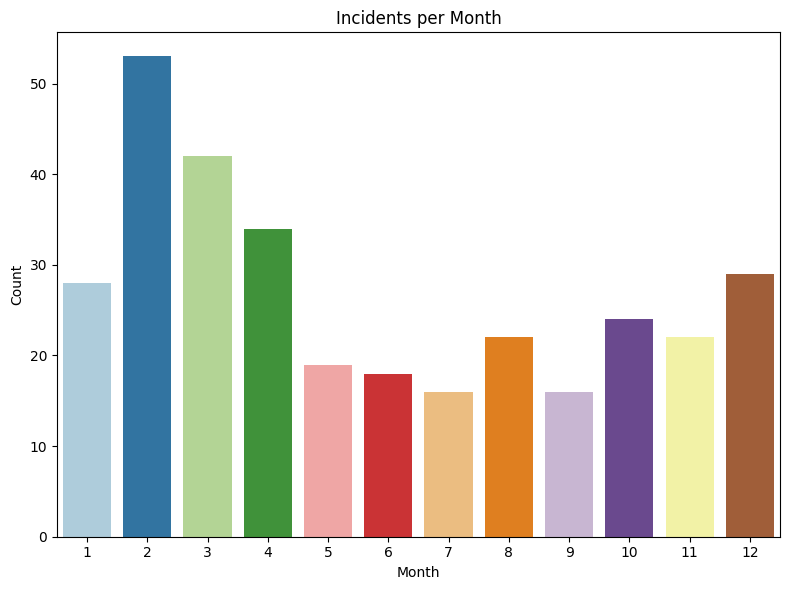

In [23]:
# Temporal analysis: incidents per month
filtered_data['Date'] = pd.to_datetime(filtered_data['Date'])
filtered_data['Month'] = filtered_data['Date'].dt.month
plt.figure(figsize=(8, 6))
sns.countplot(x='Month', data=filtered_data, palette='Paired')
plt.title('Incidents per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Each bar represents a month of the year, and its height corresponds to the count of incidents that took place during that month. The x-axis indicates the months, while the y-axis displays the count of incidents.
By examining this plot, we can observe the distribution of incidents across different months. In this dataset, February (2) has the highest number of incidents, followed by March (3). This temporal analysis provides insights into the frequency of incidents throughout the year.

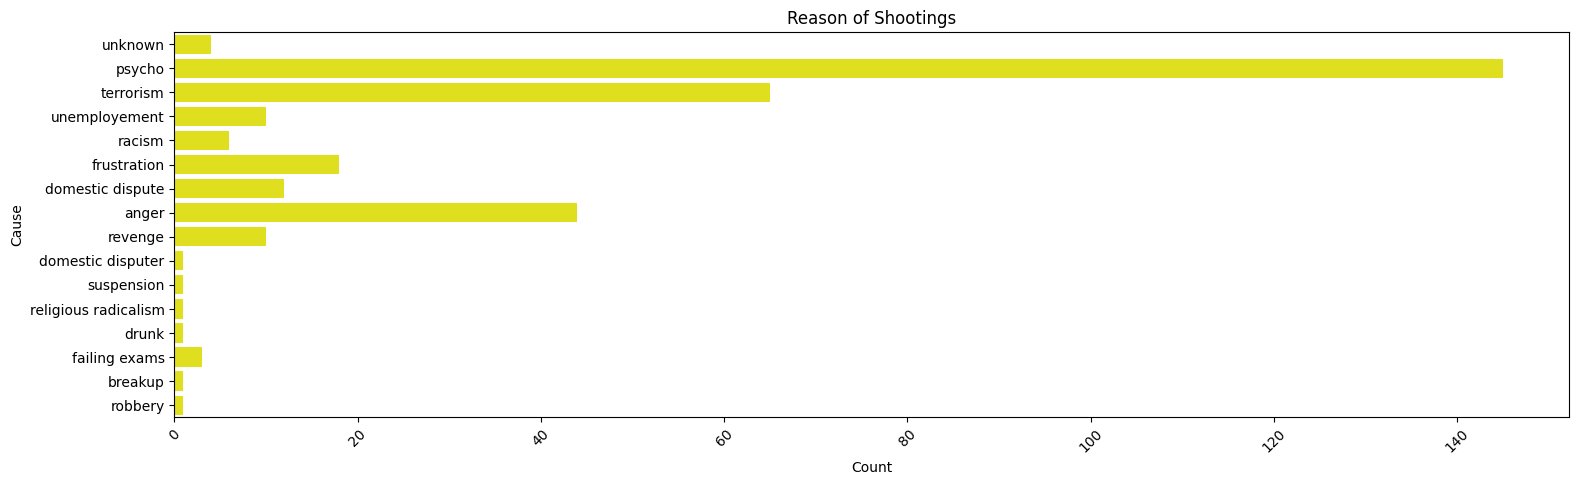

In [24]:
plt.figure(figsize=(18,5))
sns.countplot(df['Cause'], color='Yellow')
plt.xlabel('Count')
plt.xticks(rotation=45)
plt.title('Reason of Shootings')
plt.show()

Each bar represents a category of causes, and the height of the bar corresponds to the number of shootings attributed to that cause.
From the graph, we can observe:
The highest bar corresponds to the cause "Psycho", indicating that it has the highest frequency of shootings among all causes.
The second highest bar corresponds to the cause "Terrorism", indicating it has the second-highest frequency of shootings.

#### D.Maximum attacks done in a year

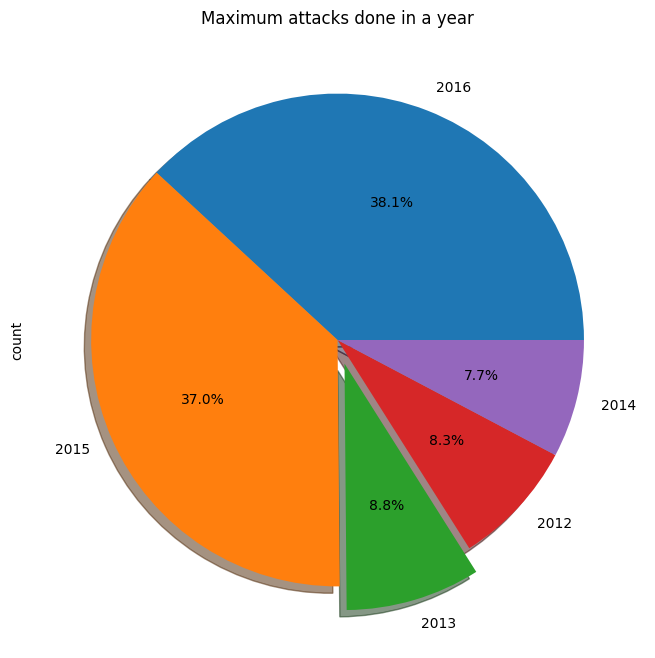

In [25]:
plt.figure(figsize=(10, 8))
df['Year'].value_counts().head().plot.pie(explode=[0, 0, 0.1, 0, 0], autopct = '%1.1f%%', shadow=True)
plt.title('Maximum attacks done in a year')
plt.show()


Each slice of the pie represents a year, and its size indicates the percentage of shootings that occurred in that year.
The explode parameter is used to highlight the slice corresponding to the year with the highest number of shootings. The slice corresponding to the year 2016 is slightly exploded, indicating it as the year with the most shootings.

## Correlation Matrix

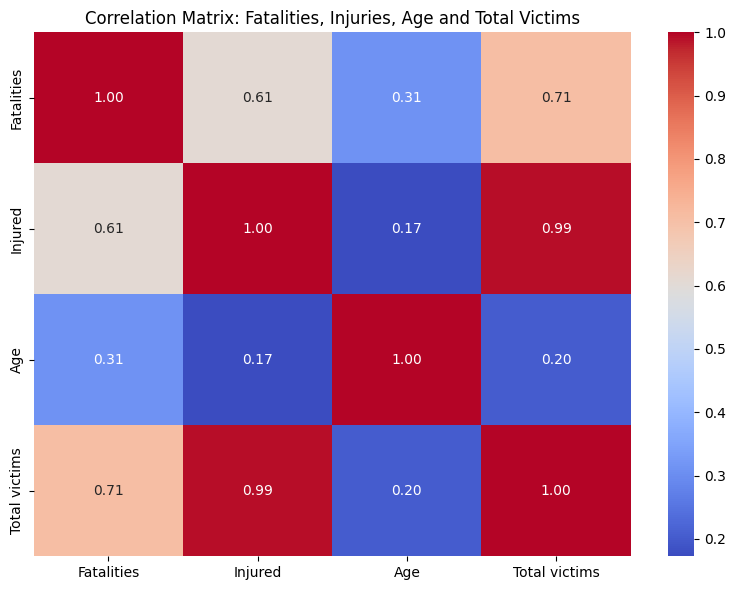

In [26]:
# Correlation matrix for selected columns
correlation_data = filtered_data[['Fatalities', 'Injured', 'Age', 'Total victims']].copy()
correlation_data['Age'] = pd.to_numeric(correlation_data['Age'], errors='coerce')  # Convert Age column to numeric
correlation_matrix = correlation_data.corr()
# Heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Fatalities, Injuries, Age and Total Victims')
plt.tight_layout()
plt.show()

This heatmap visualizes the correlation matrix of selected columns from the dataset: 'Fatalities', 'Injured', 'Age', and 'Total victims'. Here's an explanation of the output:
'Fatalities' and 'Injured' show a strong positive correlation, which is expected as higher fatalities often correspond to higher injuries.
'Age' and 'Fatalities' have a relatively weak positive correlation, suggesting that age might have a moderate influence on the number of fatalities.
'Total victims' exhibits a positive correlation with both 'Fatalities' and 'Injured', indicating that incidents with more total victims tend to have higher fatalities and injuries.
Overall, the heatmap provides valuable insights into the relationships between different variables, helping in understanding the underlying patterns in the data.

## Interactive Plots

#### Plot Generator

In [27]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# Create dropdown widgets for selecting x-axis and y-axis columns
x_dropdown = widgets.Dropdown(
    options=df.columns,
    description='Select X-axis:',
    disabled=False,
)

y_dropdown = widgets.Dropdown(
    options=df.columns,
    description='Select Y-axis:',
    disabled=False,
)

# Create dropdown widget for selecting the type of plot
plot_type_dropdown = widgets.Dropdown(
    options=['bar', 'line'],
    description='Select Plot Type:',
    disabled=False,
)

# Create a button to generate the plot
generate_button = widgets.Button(
    description='Generate Plot',
    disabled=False,
    button_style='',  # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Generate Plot',
    icon='check'
)

# Define a function to generate the plot
def generate_plot(button):
    update_plot(x_dropdown.value, y_dropdown.value, plot_type_dropdown.value)

# Attach the event handler to the button
generate_button.on_click(generate_plot)

# Define a function to update the plot based on selected options
def update_plot(x_column, y_column, plot_type):
    if x_column and y_column and plot_type:
        if plot_type == 'scatter':
            fig = px.scatter(df, x=x_column, y=y_column, title=f'{plot_type.capitalize()} Plot')
        elif plot_type == 'line':
            fig = px.line(df, x=x_column, y=y_column, title=f'{plot_type.capitalize()} Plot')
        elif plot_type == 'bar':
            fig = px.bar(df, x=x_column, y=y_column, title=f'{plot_type.capitalize()} Plot')
        elif plot_type == 'box':
            fig = px.box(df, x=x_column, y=y_column, title=f'{plot_type.capitalize()} Plot')

        fig.show()

# Display the dropdown widgets and button
display(x_dropdown)
display(y_dropdown)
display(plot_type_dropdown)
display(generate_button)


Dropdown(description='Select X-axis:', options=('S#', 'Title', 'Location', 'Date', 'Incident Area', 'Open/Clos…

Dropdown(description='Select Y-axis:', options=('S#', 'Title', 'Location', 'Date', 'Incident Area', 'Open/Clos…

Dropdown(description='Select Plot Type:', options=('bar', 'line'), value='bar')

Button(description='Generate Plot', icon='check', style=ButtonStyle(), tooltip='Generate Plot')

The plot generated by this code depends on the selections made by the user:

X-axis and Y-axis: The user can choose which columns from the DataFrame (df) to use as the X-axis and Y-axis variables. These selections determine the data to be plotted along the horizontal and vertical axes, respectively.
Plot Type: The user can select either a bar plot or a line plot for visualization. If "bar" is selected, the plot will display bars representing the data. If "line" is selected, the plot will display a line connecting the data points.
Generate Plot Button: After making the selections, the user clicks the "Generate Plot" button to generate the plot based on the chosen X-axis, Y-axis, and plot type. Choosing the reasonable features from X and Y axis gives a better insights rather than choosing random features which do not produce meaningfull insights. 

The resulting plot is interactive and will be displayed below the dropdown menus and button. Depending on the selections made, the plot may show trends, relationships, or distributions present in the dataset, providing insights into the data. You can hover your cursor over any bar or line on the plot, you'll see more information about that specific incident, like the location and the number of fatalities for example.


#### Slider Plot

In [28]:
# Create a function to update the plot based on the range of fatalities
def update_plot(min_fatalities, max_fatalities, plot_type):
    filtered_df = df[(df['Fatalities'] >= min_fatalities) & (df['Fatalities'] <= max_fatalities)]
    fig = px.scatter(filtered_df, x='Location', y='Fatalities', title='Fatalities by Location')
    fig.show()

# Define the range of fatalities using sliders
min_fatalities_slider = widgets.IntSlider(
    value=df['Fatalities'].min(),
    min=df['Fatalities'].min(),
    max=df['Fatalities'].max(),
    step=1,
    description='Min Fatalities:',
    continuous_update=False
)

max_fatalities_slider = widgets.IntSlider(
    value=df['Fatalities'].max(),
    min=df['Fatalities'].min(),
    max=df['Fatalities'].max(),
    step=1,
    description='Max Fatalities:',
    continuous_update=False
)

# Define a function to handle changes in the slider values
def slider_eventhandler(change):
    update_plot(min_fatalities_slider.value, max_fatalities_slider.value, plot_type_dropdown.value)

# Attach the event handler to the sliders
min_fatalities_slider.observe(slider_eventhandler, names='value')
max_fatalities_slider.observe(slider_eventhandler, names='value')

# Display the sliders
display(min_fatalities_slider)
display(max_fatalities_slider)

# Initial display
update_plot(min_fatalities_slider.value, max_fatalities_slider.value, plot_type_dropdown.value)


IntSlider(value=0, continuous_update=False, description='Min Fatalities:', max=59)

IntSlider(value=59, continuous_update=False, description='Max Fatalities:', max=59)

There are two sliders—one for choosing the minimum number of fatalities and the other for the maximum. You can slide these to pick the range you're interested in.
When you move the sliders, the plot updates automatically to reflect your chosen range.
If you hover your cursor over any dot on the plot, you'll see more information about that specific incident, like the location and the number of fatalities.
New graph will be visualized when changing the range. 
Choose a close range in between for better insights and details.

## MAPS

#### Point Map

C:\Users\cheta\AppData\Local\Temp\ipykernel_136724\2105666623.py:6: FutureWarning:

The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.



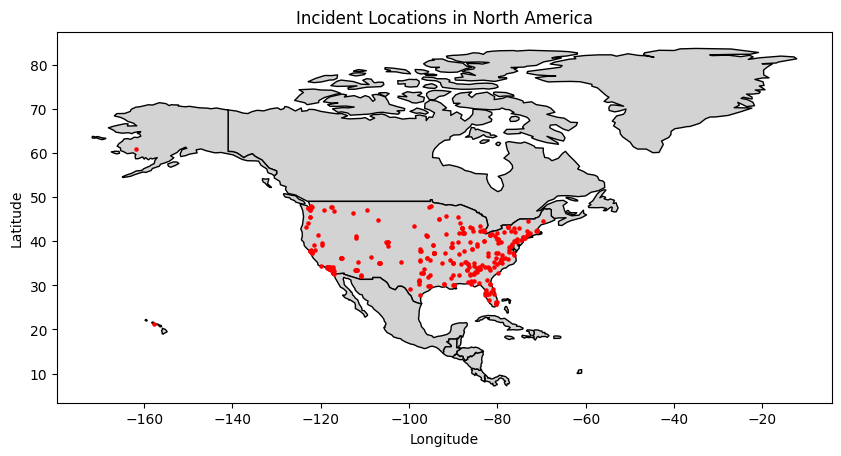

In [29]:
# Create a GeoDataFrame from the DataFrame
geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Load the world map data and filter to include only North America
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
north_america = world[world['continent'] == 'North America']

# Plot the map of North America
ax = north_america.plot(figsize=(10, 10), color='lightgray', edgecolor='black')

# Scatter plot the incident locations on top of the map, coloring them based on some attribute
gdf.plot(ax=ax, color='red', marker='o', markersize=5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Incident Locations in North America')
plt.show()

"Point Map with Basemap Overlay".This map visualizes the geographical distribution of incidents from the dataset. Each red marker represents an incident location, with the marker size indicating the severity or number of fatalities. The map provides insight into the spatial patterns of incidents and can help identify areas with higher incident rates.

#### Mapbox map

In [30]:
import plotly.express as px

fig = px.scatter_mapbox(df, lat="Latitude", lon="Longitude", color="Fatalities", 
                        color_continuous_scale=px.colors.sequential.Reds, 
                        hover_name="Location", hover_data=["Fatalities", "Injured"],
                        zoom=3, height=600)
fig.update_layout(mapbox_style="carto-darkmatter", 
                  mapbox_zoom=3, mapbox_center={"lat": df['Latitude'].mean(), "lon": df['Longitude'].mean()})
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


"scatter plot overlaid on a Mapbox map." It visualizes the locations where incidents occurred by plotting points on a map. Each point corresponds to a specific incident location, with the color indicating the severity of the incident based on the number of fatalities. Lighter shades of red represent fewer fatalities, while darker shades indicate more fatalities. Additionally, hovering over each point reveals details such as the location name, number of fatalities, and number of injured individuals. Users can interact with the map by zooming in/out, panning across different areas, and exploring the incidents in greater detail.

#### Heat Map

In [31]:
# Filter out rows with missing latitude and longitude values
filtered_data = df.dropna(subset=['Latitude', 'Longitude'])

# Create a map centered at the mean latitude and longitude of the incidents with size 400px by 400px
map_center = [filtered_data['Latitude'].mean(), filtered_data['Longitude'].mean()]
map_us = folium.Map(location=map_center, zoom_start=4, width=800, height=600)


# Convert the incident locations to a list of tuples (latitude, longitude)
locations = list(zip(filtered_data['Latitude'], filtered_data['Longitude']))

# Create a heatmap using Folium's HeatMap plugin
HeatMap(locations).add_to(map_us)

# Display the map
map_us

This visualization is like a weather map, but instead of showing temperature variations, it displays the density of incidents in different areas. The colors on the map tell us how many incidents happened in each spot, with hotter colors showing more incidents and cooler colors showing fewer. It's like looking at a heat map of activity across a region, helping us understand where incidents are clustered and where they're less common. You can explore the map by zooming in and out or hovering over specific points to see more details about each incident.

### HoloViews

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
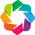

:Points   [Longitude,Latitude]   (Fatalities,Injured)

In [32]:
import holoviews as hv
from holoviews import opts# Activate the extension for the desired plotting backend
hv.extension('bokeh')  # Use 'matplotlib' if you prefer Matplotlib as the backend

# Define the visualization using Holoviews
points = hv.Points(df, ['Longitude', 'Latitude'], ['Fatalities', 'Injured'])

# Customize the plot options
opts.defaults(
    opts.Points(size=10, color='red', cmap='viridis', tools=['hover'], title='Fatalities and Injured by Location')
)

# Render the plot
points



this is an interactive scatter plot where each point represents an incident location, with the size and color of the points indicating the number of fatalities and injured individuals, respectively. Users can hover over the points to view additional information